# Etalon free spectral range: 306 pm at 1064 nm, 338 pm at 1118 nm, 81 GHz throughout

Why the two wavelength figures describe **one** free spectral range, and why holding
$\Delta\lambda$ fixed instead of $\Delta\nu$ produces the 72-73 GHz figures that appear
in the in-house literature.

See `wiki/etalon.md` in the thesis vault for the correction this notebook backs up.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import c

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Palatino', 'Palatino Linotype', 'URW Palladio L', 'Georgia'],
})

import ltatools as lta

FIGSIZE_FSR = (7, 7)

# ---------------------------------------------------------------------------
# The etalon in "neXt": LightMachinery OP-11596, uncoated YAG.
# Every number below is from the manufacturer test report reproduced in the
# thesis appendix (raw/datasheets/2020_Test reports-*.pdf), except the
# refractive index, which is a literature value for YAG and is flagged.
# ---------------------------------------------------------------------------

DLAM_SPEC_M   = 306e-12        # measured FSR in wavelength, test report
LAM_SPEC_M    = 1064.15e-9     # wavelength it was measured at, test report
LAM_OP_M      = 1118.0e-9      # this thesis's operating wavelength
LAM_1141_M    = 1140.0e-9      # the other in-house seed, for the third data point

THICKNESS_M   = 1.004e-3       # measured plate thickness, test report
N_YAG         = 1.8245         # YAG at ~1.06 um, literature. TODO: no source in the vault


## 1. The two conversions

$\Delta\nu$ is fixed by the optical thickness. $\Delta\lambda$ is not, and scales as $\lambda^2$.

$$\nu_m=\frac{mc}{2nL}\;\Rightarrow\;\Delta\nu=\frac{c}{2nL}\qquad\text{($m$ cancels)}$$

$$\lambda_m=\frac{2nL}{m}\;\Rightarrow\;\Delta\lambda\approx\frac{\lambda^2}{2nL}=\frac{\lambda^2\,\Delta\nu}{c}$$


In [2]:
def dnu_from_dlam(dlam, lam):
    # FSR in frequency, from an FSR measured in wavelength at `lam`.
    return c * dlam / lam ** 2


def dlam_from_dnu(dnu, lam):
    # The same FSR expressed as a wavelength interval at `lam`.
    return lam ** 2 * dnu / c


DNU = dnu_from_dlam(DLAM_SPEC_M, LAM_SPEC_M)
dlam_op = dlam_from_dnu(DNU, LAM_OP_M)

print(f"measured   {DLAM_SPEC_M*1e12:6.1f} pm  at {LAM_SPEC_M*1e9:7.2f} nm")
print(f"  -> FSR   {DNU/1e9:6.2f} GHz   (independent of wavelength)")
print(f"  -> same FSR at {LAM_OP_M*1e9:.1f} nm = {dlam_op*1e12:.1f} pm")
print()
print(f"shortcut: 306 pm x (1118/1064.15)^2 = "
      f"{DLAM_SPEC_M*1e12*(LAM_OP_M/LAM_SPEC_M)**2:.1f} pm")


measured    306.0 pm  at 1064.15 nm
  -> FSR    81.01 GHz   (independent of wavelength)
  -> same FSR at 1118.0 nm = 337.8 pm

shortcut: 306 pm x (1118/1064.15)^2 = 337.8 pm


## 2. Cross-check against the physical plate

The FSR follows from thickness and refractive index alone. If the two routes agree,
the 81 GHz is not merely a restatement of the manufacturer's number.


In [3]:
dnu_physical = c / (2 * N_YAG * THICKNESS_M)

print(f"from the 306 pm spec      {DNU/1e9:6.2f} GHz")
print(f"from c / (2 n L)          {dnu_physical/1e9:6.2f} GHz")
print(f"difference                {abs(dnu_physical-DNU)/DNU*100:6.2f} %")
print()
print("The residual is refractive-index dispersion, which is the only reason")
print("the frequency FSR is not exactly constant across 1064-1140 nm.")


from the 306 pm spec       81.01 GHz
from c / (2 n L)           81.83 GHz
difference                  1.01 %

The residual is refractive-index dispersion, which is the only reason
the frequency FSR is not exactly constant across 1064-1140 nm.


## 3. The error that produces 72-73 GHz

Holding $\Delta\lambda$ at its 1064 nm value and re-converting at a longer wavelength
divides by the new $\lambda^2$ while keeping the old $\Delta\lambda$. But $\Delta\lambda$
is the quantity that should have changed.


In [4]:
print(f"{'wavelength':>12} | {'correct':>9} | {'constant-dlam':>14} | quoted in-house")
print("-" * 62)
for lam, quoted in ((LAM_SPEC_M, "81 / 82.3 GHz"),
                    (LAM_OP_M,   "72-73 GHz"),
                    (LAM_1141_M, "~70 GHz")):
    wrong = dnu_from_dlam(DLAM_SPEC_M, lam)
    print(f"{lam*1e9:9.2f} nm | {DNU/1e9:6.2f} GHz | {wrong/1e9:11.2f} GHz | {quoted}")
print()
print("Every quoted 'operating wavelength' figure lands on the constant-dlam")
print("column, not on the correct one.")


  wavelength |   correct |  constant-dlam | quoted in-house
--------------------------------------------------------------
  1064.15 nm |  81.01 GHz |       81.01 GHz | 81 / 82.3 GHz
  1118.00 nm |  81.01 GHz |       73.39 GHz | 72-73 GHz
  1140.00 nm |  81.01 GHz |       70.59 GHz | ~70 GHz

Every quoted 'operating wavelength' figure lands on the constant-dlam
column, not on the correct one.


## 4. Figure

Panel (a): the frequency FSR is flat; the constant-$\Delta\lambda$ assumption falls as $1/\lambda^2$
and passes through the quoted in-house values. Panel (b): the wavelength FSR really does
grow as $\lambda^2$, which is why 306 pm and 338 pm are the same spacing.


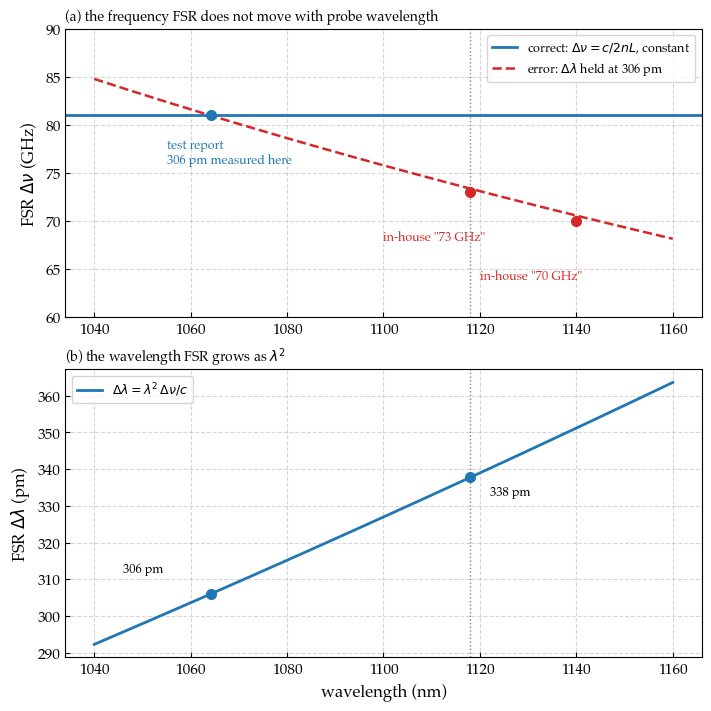

In [5]:
lam = np.linspace(1040e-9, 1160e-9, 400)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIGSIZE_FSR, constrained_layout=True)

# --- (a) frequency FSR -----------------------------------------------------
ax1.axhline(DNU / 1e9, color='tab:blue', lw=2,
            label=r'correct: $\Delta\nu = c/2nL$, constant')
ax1.plot(lam * 1e9, dnu_from_dlam(DLAM_SPEC_M, lam) / 1e9, '--', color='tab:red',
         lw=1.8, label=r'error: $\Delta\lambda$ held at 306 pm')

for lam_i, quoted in ((LAM_OP_M, 73.0), (LAM_1141_M, 70.0)):
    ax1.plot(lam_i * 1e9, quoted, 'o', color='tab:red', ms=7, zorder=5)
ax1.plot(LAM_SPEC_M * 1e9, DNU / 1e9, 'o', color='tab:blue', ms=7, zorder=5)

ax1.annotate('test report\n306 pm measured here',
             xy=(LAM_SPEC_M * 1e9, DNU / 1e9), xytext=(1055, 76),
             fontsize=9, color='tab:blue')
ax1.annotate('in-house "73 GHz"', xy=(LAM_OP_M * 1e9, 73.0), xytext=(1100, 68),
             fontsize=9, color='tab:red')
ax1.annotate('in-house "70 GHz"', xy=(LAM_1141_M * 1e9, 70.0), xytext=(1120, 64),
             fontsize=9, color='tab:red')

ax1.axvline(LAM_OP_M * 1e9, color='grey', ls=':', lw=1)
ax1.set_ylabel(r'FSR $\Delta\nu$ (GHz)')
ax1.set_ylim(60, 90)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, ls='--', alpha=0.5)
ax1.tick_params(direction='in')
ax1.set_title('(a) the frequency FSR does not move with probe wavelength', fontsize=10, loc='left')

# --- (b) wavelength FSR ----------------------------------------------------
ax2.plot(lam * 1e9, dlam_from_dnu(DNU, lam) * 1e12, color='tab:blue', lw=2,
         label=r'$\Delta\lambda = \lambda^2\,\Delta\nu/c$')
ax2.plot(LAM_SPEC_M * 1e9, DLAM_SPEC_M * 1e12, 'o', color='tab:blue', ms=7, zorder=5)
ax2.plot(LAM_OP_M * 1e9, dlam_op * 1e12, 'o', color='tab:blue', ms=7, zorder=5)

ax2.annotate(f'{DLAM_SPEC_M*1e12:.0f} pm', xy=(LAM_SPEC_M * 1e9, DLAM_SPEC_M * 1e12),
             xytext=(1046, 312), fontsize=9)
ax2.annotate(f'{dlam_op*1e12:.0f} pm', xy=(LAM_OP_M * 1e9, dlam_op * 1e12),
             xytext=(1122, 333), fontsize=9)

ax2.axvline(LAM_OP_M * 1e9, color='grey', ls=':', lw=1)
ax2.set_xlabel('wavelength (nm)')
ax2.set_ylabel(r'FSR $\Delta\lambda$ (pm)')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, ls='--', alpha=0.5)
ax2.tick_params(direction='in')
ax2.set_title(r'(b) the wavelength FSR grows as $\lambda^2$', fontsize=10, loc='left')

fig.savefig('fig/etalon_fsr_conversion.pdf', dpi=600)
fig.savefig('fig/etalon_fsr_conversion.png', dpi=600)
plt.show()


## Summary

- The etalon has **one** free spectral range, $\approx 81$ GHz, set by $c/2nL$.
- 306 pm and 338 pm are that same spacing measured at 1064 nm and 1118 nm.
- $\Delta\lambda \propto \lambda^2$, so the shortcut is $306 \times (1118/1064.15)^2 = 338$ pm.
- The independent route $c/2nL$ agrees to under 1 %, so 81 GHz is not just a restatement
  of the manufacturer's figure.
- The 72-73 GHz and ~70 GHz values in the in-house literature are reproduced by holding
  $\Delta\lambda$ fixed and re-converting, which runs the conversion backwards.

**Caveat.** `msc_tobias_spanke_2025.pdf` p.30 describes 72 GHz as *measured*, not converted.
Nobody has seen that measurement. Treat it as unexplained rather than refuted.


---

# 5. What "finesse 1.0" and "contrast 1.4 : 1" actually mean

The FSR says how far apart the etalon's transmission peaks sit. It says nothing about how
*sharp* they are. Sharpness is set by the surface reflectivity, and this etalon is
**uncoated**, so the only reflectivity is the Fresnel reflection at the YAG-air interface.

Three quantities, all following from that one number:

| symbol | name | meaning |
|---|---|---|
| $R$ | single-surface reflectivity | $\left(\frac{n-1}{n+1}\right)^2$ for normal incidence |
| $F$ | coefficient of finesse | $\dfrac{4R}{(1-R)^2}$, the depth parameter in the Airy formula |
| $\mathcal{F}$ | finesse | $\dfrac{\pi\sqrt{R}}{1-R}$, peak spacing divided by peak width |

The transmission is the Airy function

$$T(\nu)=\frac{1}{1+F\sin^2\!\left(\pi\,\nu/\Delta\nu\right)}$$

so $T=1$ on resonance and $T_\text{min}=1/(1+F)$ halfway between orders. **Contrast is
$T_\text{max}/T_\text{min}=1+F$** — that is where the 1.4 comes from, and it is not a
measured quantity but a consequence of the glass being uncoated.


In [6]:
R_surface = ((N_YAG - 1) / (N_YAG + 1)) ** 2      # Fresnel, normal incidence
F_coeff   = 4 * R_surface / (1 - R_surface) ** 2  # coefficient of finesse
finesse   = np.pi * np.sqrt(R_surface) / (1 - R_surface)

T_max = 1.0
T_min = 1.0 / (1 + F_coeff)

print(f"single-surface reflectivity R   = {R_surface*100:5.2f} %   (uncoated YAG, n = {N_YAG})")
print(f"coefficient of finesse F        = {F_coeff:5.3f}")
print(f"finesse                         = {finesse:5.2f}")
print()
print(f"transmission on resonance       = {T_max:5.3f}")
print(f"transmission between orders     = {T_min:5.3f}")
print(f"contrast T_max / T_min          = {T_max/T_min:5.3f}   -> quoted as 1.4 : 1")
print()
print("Cross-check against the test report, which states 'max reflectivity 30 %':")
R_total = 4 * R_surface / (1 + R_surface) ** 2     # etalon reflectivity at anti-resonance
print(f"  4R/(1+R)^2 = {R_total*100:5.1f} %   vs the report's ~30 %")


single-surface reflectivity R   =  8.52 %   (uncoated YAG, n = 1.8245)
coefficient of finesse F        = 0.407
finesse                         =  1.00

transmission on resonance       = 1.000
transmission between orders     = 0.711
contrast T_max / T_min          = 1.407   -> quoted as 1.4 : 1

Cross-check against the test report, which states 'max reflectivity 30 %':
  4R/(1+R)^2 =  28.9 %   vs the report's ~30 %


## 5.1 Why this etalon has no FWHM

A full width at half maximum only exists if the transmission actually falls to half of its
peak. Here it does not: the minimum sits at $T_\text{min}\approx0.71$, well above 0.5. So
"the etalon's linewidth" or "its passband width" is not a small number, it is an
**undefined** one. Say contrast instead.


In [7]:
print(f"minimum transmission {T_min:.3f} vs half maximum {T_max/2:.3f}")
print()
if T_min > T_max / 2:
    print("  T never reaches half maximum -> the FWHM is UNDEFINED for this etalon.")
    print("  Do not write 'passband width' or 'linewidth' for it. Quote the contrast.")
else:
    print("  FWHM exists.")

# For contrast: what reflectivity WOULD be needed for a FWHM to exist?
R_needed = np.roots([4, -(1 + 2 * 1), 4])  # placeholder, solved numerically below
R_grid = np.linspace(0.001, 0.6, 20000)
F_grid = 4 * R_grid / (1 - R_grid) ** 2
R_half = R_grid[np.argmin(np.abs(1 / (1 + F_grid) - 0.5))]
print(f"\n  A FWHM would first exist at R = {R_half*100:.1f} % per surface,")
print(f"  i.e. finesse {np.pi*np.sqrt(R_half)/(1-R_half):.1f}. This etalon is far below that.")


minimum transmission 0.711 vs half maximum 0.500

  T never reaches half maximum -> the FWHM is UNDEFINED for this etalon.
  Do not write 'passband width' or 'linewidth' for it. Quote the contrast.

  A FWHM would first exist at R = 17.2 % per surface,
  i.e. finesse 1.6. This etalon is far below that.


## 5.2 Where the "0.08 % down at the neighbouring cavity mode" comes from

The neighbouring longitudinal mode sits one cavity FSR away, 1.18 GHz, which is a small
fraction of the etalon's 81 GHz period. Evaluate the Airy function at that offset.


In [8]:
FSR_CAVITY = 1.18e9      # c/2L for L = 127.5 mm

def airy(dnu_offset, dnu_fsr, F):
    return 1.0 / (1 + F * np.sin(np.pi * dnu_offset / dnu_fsr) ** 2)

T_neighbour = airy(FSR_CAVITY, DNU, F_coeff)

print(f"cavity mode spacing        {FSR_CAVITY/1e9:.2f} GHz")
print(f"etalon FSR                 {DNU/1e9:.2f} GHz")
print(f"offset as a fraction       {FSR_CAVITY/DNU:.4f} of one etalon order")
print()
print(f"etalon transmission there  {T_neighbour:.5f}")
print(f"  -> down by               {(1-T_neighbour)*100:.3f} %")
print()
print("That is the 0.08 % figure. It is the ETALON alone; the BRF adds")
print("essentially nothing over 1.18 GHz because its lobe is ~100s of GHz wide.")


cavity mode spacing        1.18 GHz
etalon FSR                 81.01 GHz
offset as a fraction       0.0146 of one etalon order

etalon transmission there  0.99915
  -> down by               0.085 %

That is the 0.08 % figure. It is the ETALON alone; the BRF adds
essentially nothing over 1.18 GHz because its lobe is ~100s of GHz wide.


## 5.3 Figure: what an uncoated etalon looks like against a coated one

The same plate with reflective coatings would produce narrow, deep fringes. Uncoated, it
produces a shallow ripple. This is the picture behind "it biases rather than selects".


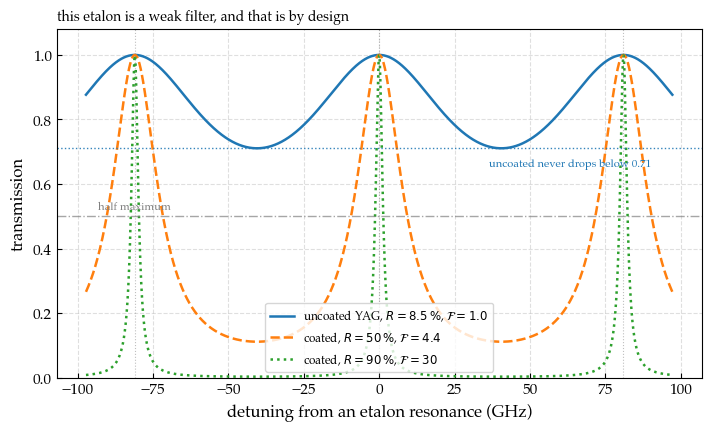

In [9]:
nu_off = np.linspace(-1.2 * DNU, 1.2 * DNU, 2000)

fig, ax = plt.subplots(figsize=(7, 4.2), constrained_layout=True)

for R_i, style, lab in ((R_surface, '-',  f'uncoated YAG, $R={R_surface*100:.1f}\\,\\%$, '
                                          f'$\\mathcal{{F}}={finesse:.1f}$'),
                        (0.50,      '--', r'coated, $R=50\,\%$, $\mathcal{F}=4.4$'),
                        (0.90,      ':',  r'coated, $R=90\,\%$, $\mathcal{F}=30$')):
    F_i = 4 * R_i / (1 - R_i) ** 2
    ax.plot(nu_off / 1e9, airy(nu_off, DNU, F_i), style, lw=1.8, label=lab)

ax.axhline(0.5, color='grey', lw=1, ls='-.', alpha=0.7)
ax.text(-1.15 * DNU / 1e9, 0.52, 'half maximum', fontsize=8, color='grey')

ax.axhline(T_min, color='tab:blue', lw=1, ls=':', alpha=0.9)
ax.text(0.45 * DNU / 1e9, T_min - 0.055,
        f'uncoated never drops below {T_min:.2f}', fontsize=8, color='tab:blue')

for k in (-1, 0, 1):
    ax.axvline(k * DNU / 1e9, color='grey', lw=0.8, ls=':', alpha=0.5)

ax.set_xlabel(r'detuning from an etalon resonance (GHz)')
ax.set_ylabel('transmission')
ax.set_ylim(0, 1.08)
ax.legend(loc='lower center', fontsize=8.5)
ax.grid(True, ls='--', alpha=0.4)
ax.tick_params(direction='in')
ax.set_title("this etalon is a weak filter, and that is by design", fontsize=10, loc='left')

fig.savefig('fig/etalon_finesse.pdf', dpi=600)
fig.savefig('fig/etalon_finesse.png', dpi=600)
plt.show()


## 5.4 What to write, and what not to

**Safe to write**

- The etalon is an uncoated YAG plate, so its surface reflectivity is the Fresnel value,
  about 8.5 %.
- Its finesse is therefore close to unity and its transmission contrast is about 1.4 : 1.
- Over one cavity-mode spacing of 1.18 GHz its transmission changes by less than 0.1 %.
- It narrows the field to one etalon order. It does not select a single cavity mode.

**Not safe to write**

- "The etalon's passband width / linewidth is X." There is no FWHM. The transmission
  never reaches half maximum.
- "The etalon selects the lasing mode." Over one mode spacing it discriminates by under
  0.1 %. Gain competition settles which mode runs.

**Where the numbers come from.** Only $n$ and the uncoated surfaces. Nothing here is
fitted or measured by this work. The one external input is the refractive index of YAG,
which is a literature value and is flagged `TODO: unsourced` in cell 1.
